<a href="https://colab.research.google.com/github/khanzaveriya/task-manager/blob/main/Project5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 1000 non-null   int64  
 1   Name               1000 non-null   object 
 2   Age                1000 non-null   int64  
 3   Gender             1000 non-null   object 
 4   Department         1000 non-null   object 
 5   Salary             1000 non-null   int64  
 6   Joining Date       1000 non-null   object 
 7   Performance Score  502 non-null    float64
 8   Experience         1000 non-null   int64  
 9   Status             1000 non-null   object 
 10  Location           1000 non-null   object 
 11  Session            1000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 93.9+ KB

=========== Shape (Rows, Columns) ============
(1000, 12)

========== STATISTICAL SUMMARY ==========
                 ID     

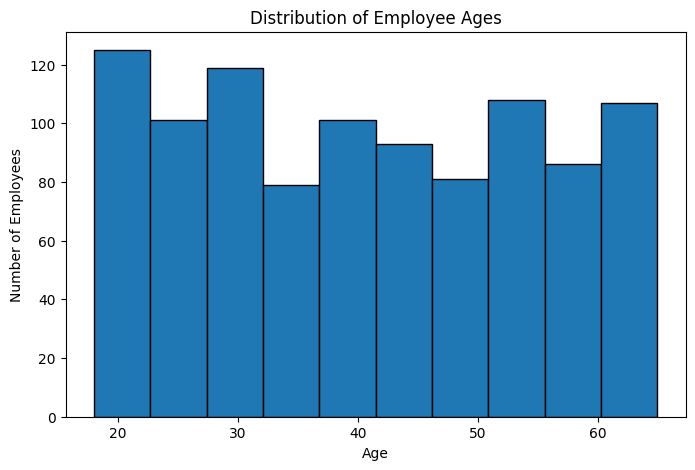

Insight:
Employee ages are fairly evenly distributed across all groups,
Indicating a balanced workforce with no dominant age range.


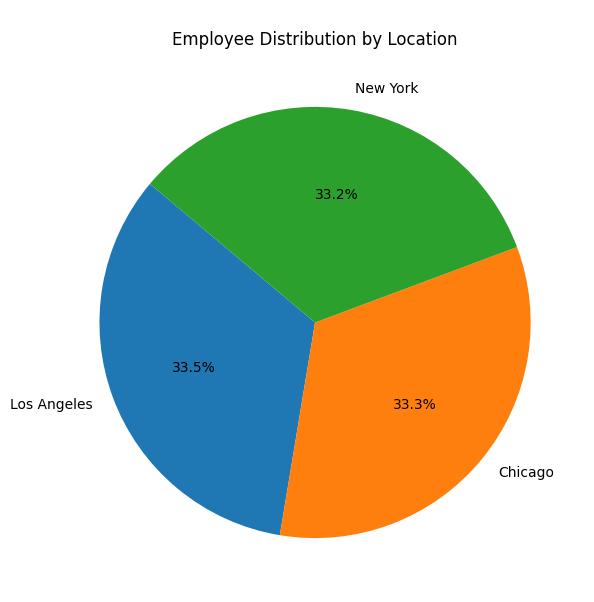

Insight:
Employees are almost equally distributed across New York, Chicago, and Los Angeles,
Indicating a balanced workforce across locations.

Employee Status Distribution:
Status
Active      501
Inactive    499
Name: count, dtype: int64
Insight:
The number of active and inactive employees is nearly equal, indicating a balanced employee status distribution.

Department with highest average performance score: IT
Highest average score: 2.9882005899705013
Insight:
The IT department has the highest average performance score (2.9), indicating
slightly better overall employee performance than other departments.


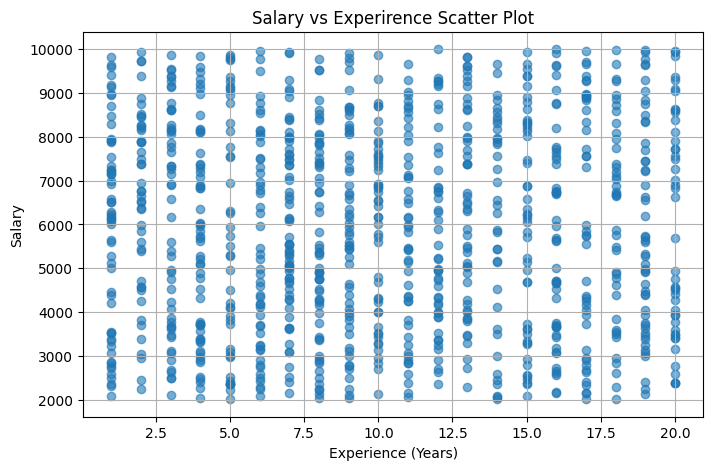

Insight:
The scatter plot shows a weak correlation between salary and experience,
as employees with different experience levels have a wide range of salaries.

=========================== Conclusion ==============================
The employee dataset contains 1,000 records with no duplicate entries and only missing
values in the Performance Score column, which were successfully handled using median
imputation.


In [28]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

df = pd.read_csv("Employe_Performance_dataset.csv")

# 3. Data Inspection

print("\n========== DATA INFO ==========")
df.info()

print("\n=========== Shape (Rows, Columns) ============")
print(df.shape)

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe(include='all'))

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== LAST 5 ROWS ==========")
print(df.tail())

print("\n========== Number of Rows ==========")
print(len(df))

print("\n========== Column Names ===========")
print(df.columns.tolist())

# 4. Data Cleaning

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())
print("Insight:")
print("The performance Score column contained 498 missing values.")
median_value = df['Performance Score'].median()
df.fillna({'Performance Score':median_value}, inplace=True)
print("\nMissing values after filling:\n",df.isnull().sum())
print("Median used:", median_value)


print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

# ANALYTICAL QUESTIONS

# Q1. What is the average salary of employees in each department?

avg_salary_by_dept = df.groupby('Department')['Salary'].mean()
print("\nAverage Salary by Department:")
print(avg_salary_by_dept)
print("Insight:")
print("HR has the highest average salary, while Sales has the lowest. The salary difference between departments is small.")

# Q2. What is the distribution of employee ages in the dataset?

print("\nAge Statistics:")
print(df['Age'].describe())
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10, edgecolor='black')
plt.title("Distribution of Employee Ages")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()
print("Insight:")
print("Employee ages are fairly evenly distributed across all groups,")
print("Indicating a balanced workforce with no dominant age range.")

# Q3. Create a pie chart showing employee distribution by location.

location_counts = df['Location'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(location_counts,labels=location_counts.index, autopct='%1.1f%%',startangle=140)
plt.title("\nEmployee Distribution by Location")
plt.show()
print("Insight:")
print("Employees are almost equally distributed across New York, Chicago, and Los Angeles,")
print("Indicating a balanced workforce across locations.")

# Q4. How many employees are active vs inactive in the company?

status_counts = df['Status'].value_counts()
print("\nEmployee Status Distribution:")
print(status_counts)
print("Insight:")
print("The number of active and inactive employees is nearly equal, indicating a balanced employee status distribution.")

# Q5. Which department has the highest average performance score?

dept_performance = df.groupby('Department')['Performance Score'].mean()
best_department = dept_performance.idxmax()
highest_score = dept_performance.max()
print("\nDepartment with highest average performance score:", best_department)
print("Highest average score:", highest_score)
print("Insight:")
print("The IT department has the highest average performance score (2.9), indicating")
print("slightly better overall employee performance than other departments.")

# Q6. Create a scatter plot between salary and experience to analyze correlation.

plt.figure(figsize=(8,5))
plt.scatter(df['Experience'], df['Salary'], alpha=0.6)
plt.title("Salary vs Experirence Scatter Plot")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.grid(True)
plt.show()
print("Insight:")
print("The scatter plot shows a weak correlation between salary and experience,")
print("as employees with different experience levels have a wide range of salaries.")


print("\n=========================== Conclusion ==============================")
print("The employee dataset contains 1,000 records with no duplicate entries and only missing")
print("values in the Performance Score column, which were successfully handled using median")
print("imputation.")